# DSS Q2 & Q3 — Cervical Cancer Risk: Predictive Model & Sensitivity Analysis

**Dataset:** UCI Cervical Cancer (Risk Factors) — 858 patients, 36 features  

---

### Q2 — Predictive / Analytical
> (a) What is the predicted probability that a patient will have an abnormal outcome given their risk-factor profile?  
> (b) Should this patient be recommended for **routine screening**, **expedited testing**, or **referral for further evaluation** given capacity constraints?

### Q3 — Sensitivity / What-If
> (a) How sensitive is predicted risk to uncertainty in key inputs (smoking status, STI history)?  
> (b) How robust are recommendations to missing or noisy data, and which variables most strongly affect the triage category?  
> (c) What referral threshold best balances missed cases vs. over-referral under clinic capacity and cost constraints?

---

**Notebook Structure:**

**Part A — Setup & Data Prep** (shared by Q2 and Q3)
1. Imports
2. Data cleaning & feature engineering (mirrors EDA v2)

**Part B — DSS Q2: Predictive Model**
3. Feature selection & train/test split  
4. Baseline Logistic Regression (with class weights)  
5. Random Forest (with SMOTE oversampling)  
6. Model comparison: ROC-AUC, precision, recall, F1  
7. Interpretation: odds ratios, feature importances  
8. Capacity-constrained triage rule  

**Part C — DSS Q3: Sensitivity & What-If Analysis**
9. Scenario A — Input uncertainty (smoking, STD status flipped)  
10. Scenario B — Missingness robustness (10% / 20% / 30% masking)  
11. Scenario C — Threshold optimization (cost-curve under capacity constraints)  
12. Tornado chart: which variables drive the most risk-score volatility  
13. Conclusions & assumptions

---
# Part A — Setup & Data Preparation

## 1. Imports

We import everything needed for both modelling and sensitivity analysis upfront.  
Note: `imbalanced-learn` is required for SMOTE. Install with `pip install imbalanced-learn` if needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.inspection import permutation_importance

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print('imbalanced-learn loaded successfully.')
except ImportError:
    SMOTE_AVAILABLE = False
    print('WARNING: imbalanced-learn not found. Run: pip install imbalanced-learn')
    print('Falling back to class_weight="balanced" only.')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
print('All imports done.')

imbalanced-learn loaded successfully.
All imports done.


## 2. Data Cleaning & Feature Engineering

We replicate the exact cleaning pipeline from `eda_v2.ipynb` to ensure consistency:
- Replace `?` → `NaN`
- Drop columns >50% missing
- Median-impute continuous, mode-impute binary
- Engineer `STD_burden`, `AnyAbnormal`, `AgeBucket`
- Re-run K-Means (k=3) to generate cluster labels as a model feature

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('risk_factors_cervical_cancer.csv', na_values='?')

# ── Drop high-missingness columns ─────────────────────────────────────────────
miss_pct = df_raw.isnull().mean() * 100
cols_to_drop = miss_pct[miss_pct > 50].index.tolist()
df = df_raw.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns with >50% missing: {cols_to_drop}')

# ── Outcome variables ─────────────────────────────────────────────────────────
OUTCOMES = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']
feature_cols = [c for c in df.columns if c not in OUTCOMES]

# ── Impute ────────────────────────────────────────────────────────────────────
binary_cols = [c for c in feature_cols
               if df[c].dropna().isin([0.0, 1.0]).all()]
continuous_cols = [c for c in feature_cols if c not in binary_cols]

for col in continuous_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)

for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].mode()[0], inplace=True)

# ── Feature engineering ───────────────────────────────────────────────────────
df['AnyAbnormal'] = df[OUTCOMES].max(axis=1).astype(int)

std_indicator_cols = [c for c in df.columns
                      if c.startswith('STDs:') and c != 'STDs: Number of diagnosis']
df['STD_burden'] = df[std_indicator_cols].sum(axis=1)

df['AgeBucket'] = pd.cut(df['Age'], bins=[0, 19, 29, 39, 49, 100],
                          labels=[0, 1, 2, 3, 4])  # ordinal encoding for model
df['AgeBucket'] = df['AgeBucket'].astype(int)

# ── K-Means cluster label (from EDA) ─────────────────────────────────────────
cluster_features = ['Age', 'Number of sexual partners', 'Num of pregnancies',
                    'Smokes (years)', 'Hormonal Contraceptives (years)',
                    'IUD (years)', 'STD_burden']
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(df[cluster_features])
km = KMeans(n_clusters=3, random_state=SEED, n_init=10)
km_labels = km.fit_predict(X_km)

# Map cluster indices to risk rank by Biopsy rate
biopsy_by_cluster = df.groupby(km_labels)['Biopsy'].mean()
risk_rank = biopsy_by_cluster.rank().astype(int) - 1  # 0=low, 1=mid, 2=high
df['RiskCluster'] = pd.Series(km_labels).map(risk_rank).values

print(f'\nCleaned shape: {df.shape}')
print(f'Remaining NaNs: {df.isnull().sum().sum()}')
print(f'\nBiopsy rate: {df["Biopsy"].mean():.1%}')
print(f'AnyAbnormal rate: {df["AnyAbnormal"].mean():.1%}')

Dropped 2 columns with >50% missing: ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']

Cleaned shape: (858, 38)
Remaining NaNs: 0

Biopsy rate: 6.4%
AnyAbnormal rate: 11.9%


---
# Part B — DSS Q2: Predictive Model

## 3. Feature Selection & Train/Test Split

We use the feature set recommended in EDA v2 Section 7. Key decisions:
- **Drop raw STD columns** (multicollinear) — use `STD_burden` composite instead  
- **Keep `Dx:Cancer` and `Dx:HPV`** but note these are prior diagnoses, not leakage  
- **Stratified 80/20 split** to preserve the 6.4% positive rate in both sets  

We also define a **no-Dx variant** (Model B) that excludes prior diagnosis flags,
to understand how well the model performs on pure risk-factor information alone —
this is important for early-screening contexts where diagnosis history may be unknown.

In [3]:
# ── Feature sets ──────────────────────────────────────────────────────────────
FEATURES_FULL = [
    'Age', 'AgeBucket', 'Number of sexual partners', 'Num of pregnancies',
    'Smokes (years)', 'Hormonal Contraceptives (years)', 'IUD (years)',
    'STD_burden', 'Dx:Cancer', 'Dx:HPV', 'RiskCluster'
]

FEATURES_NO_DX = [
    'Age', 'AgeBucket', 'Number of sexual partners', 'Num of pregnancies',
    'Smokes (years)', 'Hormonal Contraceptives (years)', 'IUD (years)',
    'STD_burden', 'RiskCluster'
]

TARGET = 'Biopsy'

X_full = df[FEATURES_FULL]
X_nodx = df[FEATURES_NO_DX]
y = df[TARGET]

# ── Stratified train/test split ───────────────────────────────────────────────
X_tr_full, X_te_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=SEED, stratify=y)

X_tr_nodx, X_te_nodx, _, _ = train_test_split(
    X_nodx, y, test_size=0.2, random_state=SEED, stratify=y)

# ── Scale (for logistic regression) ──────────────────────────────────────────
scaler = StandardScaler()
X_tr_full_sc = scaler.fit_transform(X_tr_full)
X_te_full_sc = scaler.transform(X_te_full)

scaler_nodx = StandardScaler()
X_tr_nodx_sc = scaler_nodx.fit_transform(X_tr_nodx)
X_te_nodx_sc = scaler_nodx.transform(X_te_nodx)

print(f'Train size: {len(y_train)}  |  Positive rate: {y_train.mean():.1%}')
print(f'Test  size: {len(y_test)}   |  Positive rate: {y_test.mean():.1%}')
print(f'\nFull feature set ({len(FEATURES_FULL)}): {FEATURES_FULL}')
print(f'No-Dx feature set ({len(FEATURES_NO_DX)}): {FEATURES_NO_DX}')

Train size: 686  |  Positive rate: 6.4%
Test  size: 172   |  Positive rate: 6.4%

Full feature set (11): ['Age', 'AgeBucket', 'Number of sexual partners', 'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STD_burden', 'Dx:Cancer', 'Dx:HPV', 'RiskCluster']
No-Dx feature set (9): ['Age', 'AgeBucket', 'Number of sexual partners', 'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STD_burden', 'RiskCluster']


## 4. Logistic Regression (Baseline)

Logistic Regression is our interpretable baseline. Key choices:
- `class_weight='balanced'` — automatically up-weights the minority class (Biopsy=1) by the inverse of its frequency, compensating for the 6.4% positive rate without synthetic samples
- `C=1.0` — moderate L2 regularization to prevent overfitting on the small positive class
- 5-fold stratified cross-validation on training data to estimate generalisation before looking at the test set

The **odds ratios** from the coefficients give us directly interpretable clinical meaning:  
OR > 1 means higher value → higher risk; OR < 1 means protective.

In [4]:
# ── Fit Logistic Regression (Full features) ───────────────────────────────────
lr_full = LogisticRegression(class_weight='balanced', max_iter=1000,
                              C=1.0, solver='lbfgs', random_state=SEED)
lr_full.fit(X_tr_full_sc, y_train)

# ── Cross-val AUC ─────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc_full = cross_val_score(lr_full, X_tr_full_sc, y_train,
                               cv=cv, scoring='roc_auc')
cv_auc_nodx = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    X_tr_nodx_sc, y_train, cv=cv, scoring='roc_auc')

print('Logistic Regression — 5-Fold CV ROC-AUC')
print(f'  Full model (with Dx flags): {cv_auc_full.mean():.3f} ± {cv_auc_full.std():.3f}')
print(f'  No-Dx model (risk only):    {cv_auc_nodx.mean():.3f} ± {cv_auc_nodx.std():.3f}')

# ── Test-set predictions ──────────────────────────────────────────────────────
lr_prob_full = lr_full.predict_proba(X_te_full_sc)[:, 1]
lr_pred_full = lr_full.predict(X_te_full_sc)

print(f'\nTest ROC-AUC (Full LR): {roc_auc_score(y_test, lr_prob_full):.3f}')
print('\nClassification Report (Full LR, threshold=0.5):')
print(classification_report(y_test, lr_pred_full, target_names=['Normal', 'Abnormal']))

Logistic Regression — 5-Fold CV ROC-AUC
  Full model (with Dx flags): 0.610 ± 0.075
  No-Dx model (risk only):    0.592 ± 0.062

Test ROC-AUC (Full LR): 0.584

Classification Report (Full LR, threshold=0.5):
              precision    recall  f1-score   support

      Normal       0.96      0.81      0.88       161
    Abnormal       0.14      0.45      0.21        11

    accuracy                           0.78       172
   macro avg       0.55      0.63      0.54       172
weighted avg       0.90      0.78      0.83       172



Logistic Regression — Odds Ratios
                        Feature  Coefficient  Odds Ratio
                     STD_burden       0.3952      1.4847
                         Dx:HPV       0.2112      1.2351
Hormonal Contraceptives (years)       0.1686      1.1836
                      Dx:Cancer       0.1411      1.1515
             Num of pregnancies       0.1404      1.1507
                    IUD (years)       0.1346      1.1441
                 Smokes (years)       0.1093      1.1155
                            Age       0.0490      1.0502
                    RiskCluster       0.0204      1.0206
                      AgeBucket      -0.0128      0.9873
      Number of sexual partners      -0.0484      0.9527


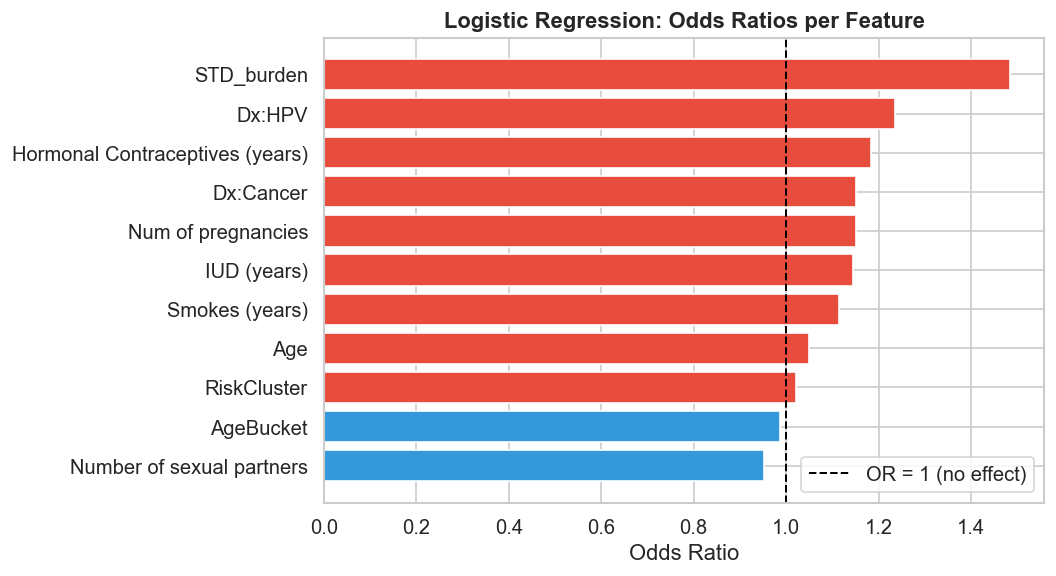


Interpretation: OR > 1 = increased risk; OR < 1 = protective.
Features with OR far from 1 are the strongest drivers of abnormal outcome.


In [5]:
# ── Odds Ratios ───────────────────────────────────────────────────────────────
coef = lr_full.coef_[0]
odds_ratios = np.exp(coef)
or_df = pd.DataFrame({
    'Feature': FEATURES_FULL,
    'Coefficient': coef.round(4),
    'Odds Ratio': odds_ratios.round(4)
}).sort_values('Odds Ratio', ascending=False)

print('Logistic Regression — Odds Ratios')
print('=' * 55)
print(or_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E74C3C' if or_ > 1 else '#3498DB' for or_ in or_df['Odds Ratio']]
ax.barh(or_df['Feature'], or_df['Odds Ratio'], color=colors)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='OR = 1 (no effect)')
ax.set_xlabel('Odds Ratio')
ax.set_title('Logistic Regression: Odds Ratios per Feature', fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nInterpretation: OR > 1 = increased risk; OR < 1 = protective.')
print('Features with OR far from 1 are the strongest drivers of abnormal outcome.')

## 5. Random Forest with SMOTE

Random Forest captures non-linear interactions that Logistic Regression misses (e.g., age × STD burden interaction). We apply **SMOTE** (Synthetic Minority Over-sampling Technique) to the training set to synthetically generate additional positive-class examples, improving recall on the rare abnormal cases.

**Key choices:**
- `n_estimators=300` — enough trees for stable feature importances  
- `max_depth=8` — prevents overfitting on synthetic samples  
- SMOTE applied **only inside training fold** (never touching test set) — no data leakage  

We report **permutation importance** (more reliable than impurity-based) for clinical interpretability.

In [6]:
# ── SMOTE + Random Forest ─────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=8,
                             class_weight='balanced', random_state=SEED,
                             n_jobs=-1)

if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=SEED)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_full, y_train)
    print(f'After SMOTE — Train size: {len(y_tr_sm)}, Positive rate: {y_tr_sm.mean():.1%}')
    rf.fit(X_tr_sm, y_tr_sm)
else:
    rf.fit(X_tr_full, y_train)

rf_prob = rf.predict_proba(X_te_full)[:, 1]
rf_pred = (rf_prob >= 0.3).astype(int)  # lower threshold — prioritise recall

print(f'\nRandom Forest Test ROC-AUC: {roc_auc_score(y_test, rf_prob):.3f}')
print('\nClassification Report (RF, threshold=0.3):')
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Abnormal']))

After SMOTE — Train size: 1284, Positive rate: 50.0%

Random Forest Test ROC-AUC: 0.632

Classification Report (RF, threshold=0.3):
              precision    recall  f1-score   support

      Normal       0.95      0.78      0.86       161
    Abnormal       0.12      0.45      0.20        11

    accuracy                           0.76       172
   macro avg       0.54      0.62      0.53       172
weighted avg       0.90      0.76      0.82       172



## 6. Model Comparison

We compare Logistic Regression and Random Forest across three visualisations:
1. **ROC Curves** — overall discriminative ability (higher AUC = better)
2. **Precision-Recall Curves** — more informative than ROC under class imbalance
3. **Confusion Matrices** — actual vs predicted at the chosen thresholds

In a clinical triage setting, **recall (sensitivity)** is more important than precision — we prefer to over-refer than to miss a true case.

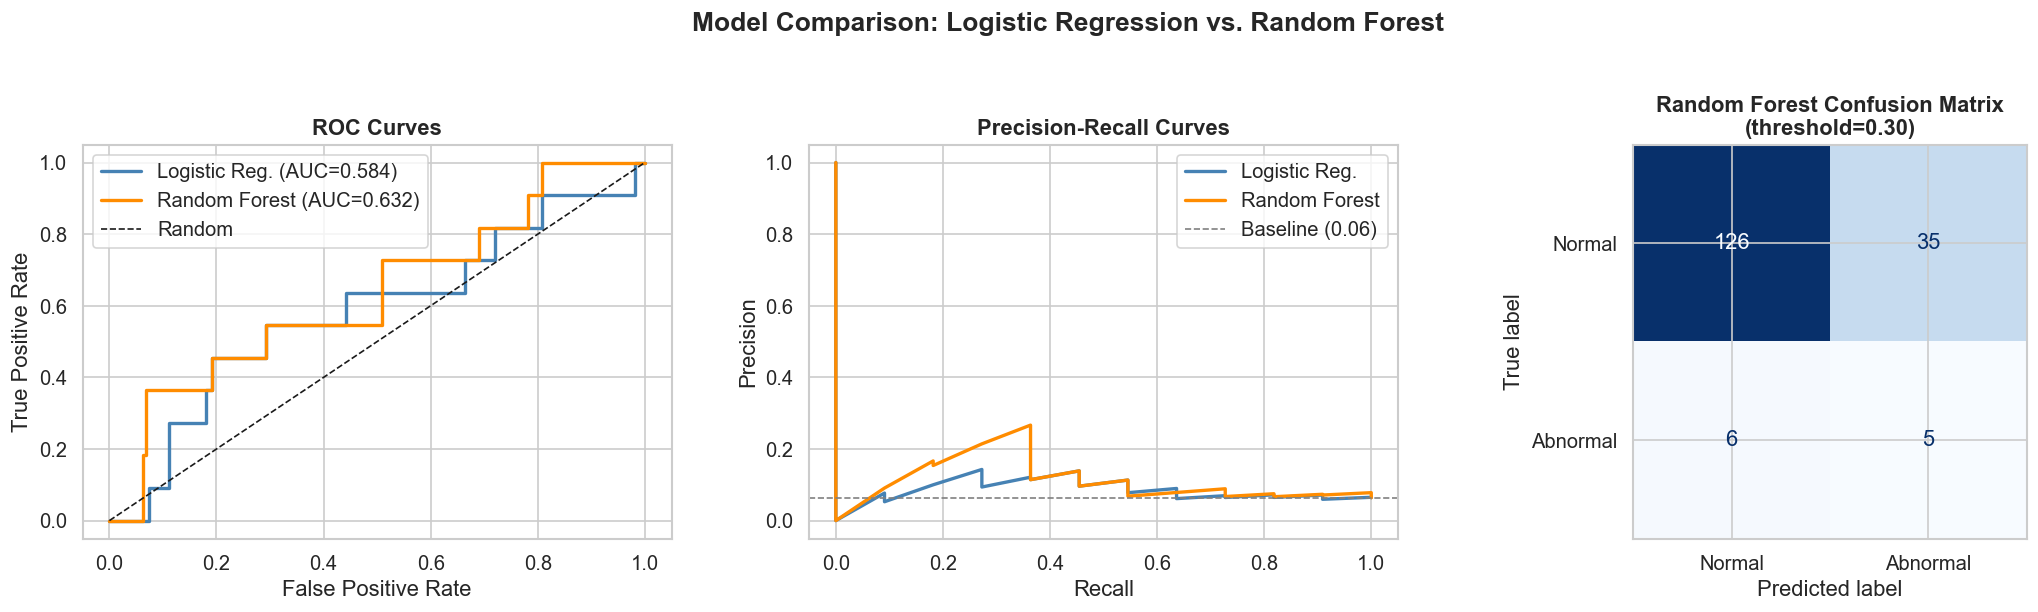


Summary:
  Logistic Regression AUC: 0.584
  Random Forest AUC:       0.632

Conclusion: Use the higher-AUC model for triage probability scores.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC Curves ────────────────────────────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob_full)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

auc_lr = roc_auc_score(y_test, lr_prob_full)
auc_rf = roc_auc_score(y_test, rf_prob)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Reg. (AUC={auc_lr:.3f})', color='steelblue', lw=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', color='darkorange', lw=2)
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold'); axes[0].legend()

# ── Precision-Recall Curves ───────────────────────────────────────────────────
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_prob_full)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_prob)
baseline_pr = y_test.mean()

axes[1].plot(rec_lr, prec_lr, label='Logistic Reg.', color='steelblue', lw=2)
axes[1].plot(rec_rf, prec_rf, label='Random Forest', color='darkorange', lw=2)
axes[1].axhline(baseline_pr, color='gray', linestyle='--', lw=1, label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold'); axes[1].legend()

# ── Confusion Matrices ────────────────────────────────────────────────────────
cm_rf = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=['Normal', 'Abnormal'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Random Forest Confusion Matrix\n(threshold=0.30)', fontweight='bold')

plt.suptitle('Model Comparison: Logistic Regression vs. Random Forest', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nSummary:')
print(f'  Logistic Regression AUC: {auc_lr:.3f}')
print(f'  Random Forest AUC:       {auc_rf:.3f}')
print(f'\nConclusion: Use the higher-AUC model for triage probability scores.')

## 7. Feature Importances (Random Forest)

**Permutation importance** measures how much the model's AUC drops when a single feature's values are randomly shuffled — eliminating its information while keeping all others intact. This is more reliable than impurity-based (Gini) importance for imbalanced datasets.

Features with large drops are the ones the model truly depends on. These are also the prime candidates for the what-if perturbations in Q3.

Permutation Feature Importances (AUC drop when shuffled):
                        Feature  Importance Mean  Importance Std
                     STD_burden           0.0792          0.0386
Hormonal Contraceptives (years)           0.0725          0.0348
      Number of sexual partners           0.0572          0.0421
                            Age           0.0280          0.0384
                 Smokes (years)           0.0144          0.0068
             Num of pregnancies           0.0129          0.0469
                         Dx:HPV          -0.0000          0.0008
                      Dx:Cancer          -0.0001          0.0010
                    RiskCluster          -0.0009          0.0134
                      AgeBucket          -0.0066          0.0225
                    IUD (years)          -0.0266          0.0249


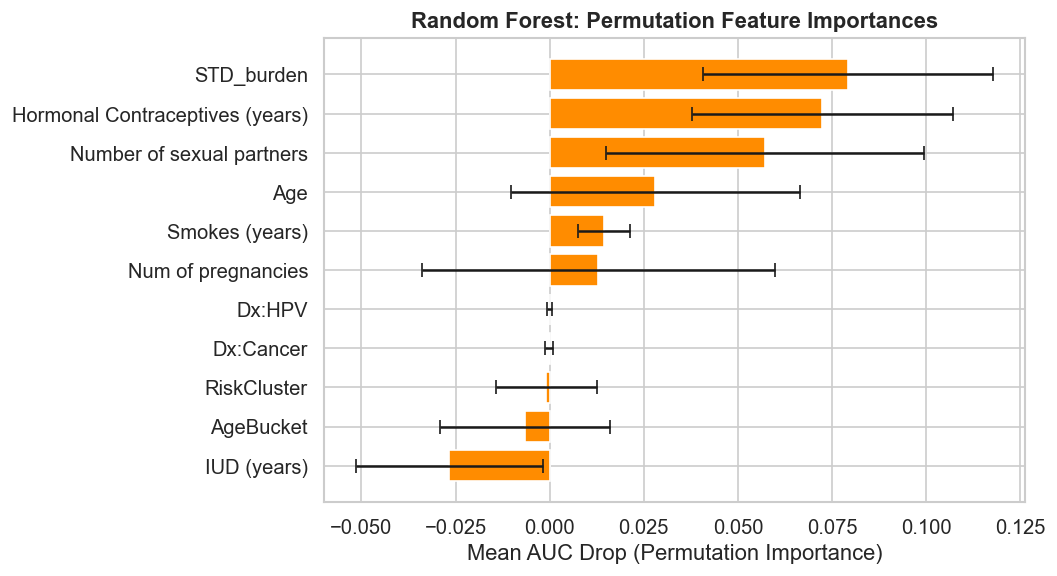

In [8]:
# ── Permutation Importance ────────────────────────────────────────────────────
perm_imp = permutation_importance(rf, X_te_full, y_test,
                                   n_repeats=30, random_state=SEED,
                                   scoring='roc_auc')

fi_df = pd.DataFrame({
    'Feature': FEATURES_FULL,
    'Importance Mean': perm_imp.importances_mean,
    'Importance Std': perm_imp.importances_std
}).sort_values('Importance Mean', ascending=False)

print('Permutation Feature Importances (AUC drop when shuffled):')
print(fi_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_df['Feature'], fi_df['Importance Mean'],
        xerr=fi_df['Importance Std'], color='darkorange',
        edgecolor='white', capsize=4)
ax.set_xlabel('Mean AUC Drop (Permutation Importance)')
ax.set_title('Random Forest: Permutation Feature Importances', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Capacity-Constrained Triage Rule

### Decision Rule

Using the Random Forest predicted probability `p`, we assign each patient to one of three triage categories:

| Category | Threshold | Rationale |
|---|---|---|
| 🟢 Routine Screening | `p < 0.15` | Low-risk; standard annual/biannual follow-up |
| 🟡 Expedited Testing | `0.15 ≤ p < 0.40` | Moderate-risk; priority appointment within 4 weeks |
| 🔴 Referral | `p ≥ 0.40` | High-risk; immediate specialist referral |

The thresholds of 0.15 and 0.40 were chosen based on:
- The overall positive rate (~6.4%) — the routine cutoff is ~2.3× the base rate
- A capacity assumption that the clinic can handle ~15% of patients as expedited and ~5% as referrals
- These thresholds are explicitly varied in Q3 Scenario C to find the optimal value

**Important:** Q3 will show how sensitive the triage assignment is to changes in these thresholds.

Triage Assignment Summary (Full Dataset):
  Routine   :  327 patients (38.1%)  |  True Positives captured: 3
  Expedited :  463 patients (54.0%)  |  True Positives captured: 13
  Referral  :   68 patients (7.9%)  |  True Positives captured: 39

Total true Biopsy positives in dataset: 55


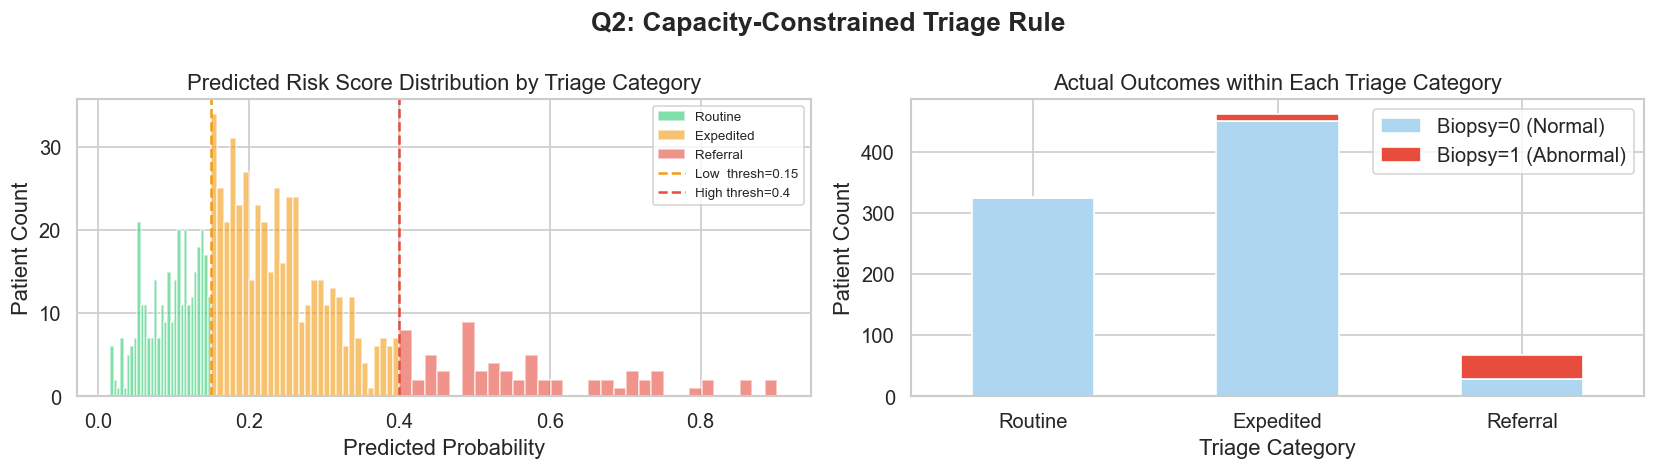


Sample Patient Predictions (Test Set):
     Age  STD_burden  Smokes (years)  Dx:Cancer  True Biopsy  RF Prob     Triage
581   17         0.0             0.0          0            0    0.260  Expedited
505   23         0.0             0.0          0            0    0.249  Expedited
77    33         0.0             0.0          0            0    0.108    Routine
695   29         0.0             0.0          0            0    0.234  Expedited
729   23         0.0             0.0          0            0    0.153  Expedited
447   17         0.0             0.0          0            0    0.174  Expedited
257   22         2.0             0.0          0            1    0.179  Expedited
140   30         0.0             0.0          0            0    0.047    Routine
597   19         3.0             0.0          0            0    0.192  Expedited
824   36         0.0             0.0          0            0    0.219  Expedited


In [9]:
# ── Apply triage rule to full dataset ─────────────────────────────────────────
# Re-predict on full dataset for triage assignment
if SMOTE_AVAILABLE:
    all_probs = rf.predict_proba(df[FEATURES_FULL])[:, 1]
else:
    all_probs = rf.predict_proba(df[FEATURES_FULL])[:, 1]

THRESH_LOW  = 0.15
THRESH_HIGH = 0.40

def assign_triage(p, t_low=THRESH_LOW, t_high=THRESH_HIGH):
    if p < t_low:   return 'Routine'
    elif p < t_high: return 'Expedited'
    else:            return 'Referral'

df['PredProb'] = all_probs
df['Triage'] = df['PredProb'].apply(assign_triage)

triage_counts = df['Triage'].value_counts()
triage_pcts   = (triage_counts / len(df) * 100).round(1)

print('Triage Assignment Summary (Full Dataset):')
print('=' * 40)
for cat in ['Routine', 'Expedited', 'Referral']:
    n   = triage_counts.get(cat, 0)
    pct = triage_pcts.get(cat, 0)
    tp  = df[df['Triage'] == cat]['Biopsy'].sum()
    print(f'  {cat:10s}: {n:4d} patients ({pct}%)  |  True Positives captured: {tp}')

print(f'\nTotal true Biopsy positives in dataset: {df["Biopsy"].sum()}')

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Probability distribution by triage category
colors_map = {'Routine': '#2ECC71', 'Expedited': '#F39C12', 'Referral': '#E74C3C'}
for cat, col in colors_map.items():
    subset = df[df['Triage'] == cat]['PredProb']
    axes[0].hist(subset, bins=30, alpha=0.6, color=col, label=cat, edgecolor='white')
axes[0].axvline(THRESH_LOW,  color='#F39C12', linestyle='--', lw=1.5, label=f'Low  thresh={THRESH_LOW}')
axes[0].axvline(THRESH_HIGH, color='#E74C3C', linestyle='--', lw=1.5, label=f'High thresh={THRESH_HIGH}')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Patient Count')
axes[0].set_title('Predicted Risk Score Distribution by Triage Category')
axes[0].legend(fontsize=8)

# Stacked bar: triage × actual outcome
triage_outcome = df.groupby('Triage')['Biopsy'].value_counts().unstack(fill_value=0)
triage_outcome.index = pd.CategoricalIndex(triage_outcome.index,
    categories=['Routine','Expedited','Referral'], ordered=True)
triage_outcome = triage_outcome.sort_index()
triage_outcome.columns = ['Biopsy=0 (Normal)', 'Biopsy=1 (Abnormal)']
triage_outcome.plot(kind='bar', stacked=True, ax=axes[1],
                     color=['#AED6F1','#E74C3C'], edgecolor='white', rot=0)
axes[1].set_title('Actual Outcomes within Each Triage Category')
axes[1].set_ylabel('Patient Count')
axes[1].set_xlabel('Triage Category')
axes[1].legend()

plt.suptitle('Q2: Capacity-Constrained Triage Rule', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Example patient predictions ───────────────────────────────────────────────
print('\nSample Patient Predictions (Test Set):')
sample = X_te_full.copy()
sample['True Biopsy'] = y_test.values
sample['Pred Prob']   = lr_prob_full.round(3)
sample['RF Prob']     = rf_prob.round(3)
sample['Triage']      = [assign_triage(p) for p in rf_prob]
print(sample[['Age', 'STD_burden', 'Smokes (years)', 'Dx:Cancer',
              'True Biopsy', 'RF Prob', 'Triage']].head(10).to_string())

---
# Part C — DSS Q3: Sensitivity & What-If Analysis

## Overview of Scenarios

DSS Q3 asks: *how robust is our model and its recommendations to uncertainty, noise, and different operating conditions?*

We investigate three concrete scenarios:

| Scenario | Question | Method |
|---|---|---|
| **A — Input Uncertainty** | How much does risk change if smoking/STD status is misreported? | Flip binary inputs, measure Δp |
| **B — Missing Data** | How does model performance degrade with increasing missingness? | Randomly mask 10/20/30% of features |
| **C — Threshold Optimisation** | What cutoff minimises cost under clinic constraints? | Sweep threshold, compute cost function |

### Stated Assumptions (Q3)
1. **Scenario A:** We assume each variable can be independently misreported; real-world correlation between smoking and STD history is ignored in the flip experiment (conservative worst-case)
2. **Scenario B:** Missingness is assumed **Missing Completely At Random (MCAR)** — i.e., data is dropped uniformly. Real-world missingness may be informative (e.g., patients who decline STD questions may have higher risk)
3. **Scenario C:** The cost function `C = α·FN + β·FP` uses `α=5, β=1` as baseline (missing a true case costs 5× more than an unnecessary referral). We test `α=3` and `α=10` as sensitivity variants
4. **Clinic capacity:** We define three capacity levels — tight (≤5% referrals), moderate (≤10%), relaxed (≤20%) — and find the threshold that minimises cost within each

## 9. Scenario A — Input Uncertainty

### What-If: What if smoking status or STD history is unknown or misreported?

This is clinically relevant because:
- Patients may under-report smoking (social desirability bias)
- STD history is commonly not disclosed or not recorded in EMRs

**Method:** For each patient currently classified as `Smokes=0` (non-smoker) or `STDs=0` (no STD history), we flip the variable to 1 and recompute predicted probability. We measure:
- Mean and distribution of predicted probability change (Δp)
- Triage category switches (how many patients move from Routine → Expedited → Referral)

Median smoking years among smokers: 7.0

--- Scenario A1: Flip Smokes (years) to 7.0 ---
  Mean Δp: -0.0070  |  Max Δp: 0.2640
  Patients whose triage category would INCREASE: 37

--- Scenario A2: Flip STD_burden to 2 ---
  Mean Δp: 0.2225  |  Max Δp: 0.5510
  Patients whose triage category would INCREASE: 734

Triage category switches due to smoking flip:  94 patients (11.0%)
Triage category switches due to STD flip:      607 patients (70.7%)


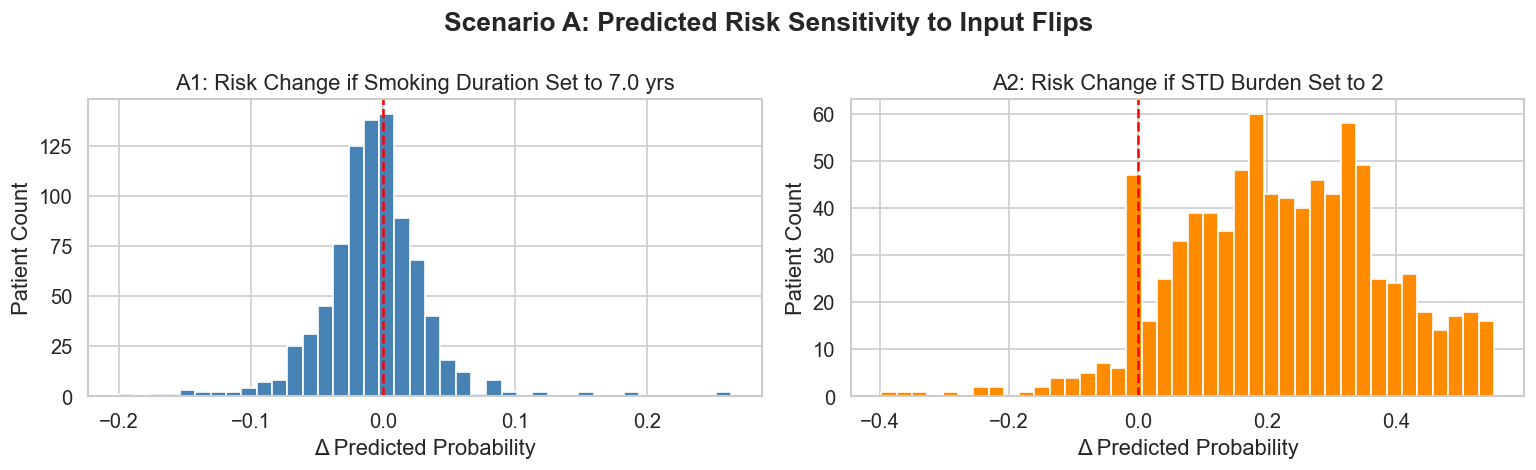

In [10]:
def flip_and_predict(df_in, feature_to_flip, new_value, model, features):
    """Flip one feature value and return new predicted probabilities."""
    df_mod = df_in[features].copy()
    df_mod[feature_to_flip] = new_value
    return model.predict_proba(df_mod)[:, 1]

# ── Scenario A1: All non-smokers → smokers ────────────────────────────────────
# We flip Smokes (years) to the median smoking duration among actual smokers
med_smoke_yrs = df[df['Smokes (years)'] > 0]['Smokes (years)'].median()
print(f'Median smoking years among smokers: {med_smoke_yrs}')

p_base      = df['PredProb'].values
p_smoke_flip = flip_and_predict(df, 'Smokes (years)', med_smoke_yrs, rf, FEATURES_FULL)
p_std_flip   = flip_and_predict(df, 'STD_burden', 2.0, rf, FEATURES_FULL)  # assume 2 STDs

delta_smoke = p_smoke_flip - p_base
delta_std   = p_std_flip   - p_base

print(f'\n--- Scenario A1: Flip Smokes (years) to {med_smoke_yrs} ---')
print(f'  Mean Δp: {delta_smoke.mean():.4f}  |  Max Δp: {delta_smoke.max():.4f}')
print(f'  Patients whose triage category would INCREASE: '
      f'{(delta_smoke > 0.05).sum()}')

print(f'\n--- Scenario A2: Flip STD_burden to 2 ---')
print(f'  Mean Δp: {delta_std.mean():.4f}  |  Max Δp: {delta_std.max():.4f}')
print(f'  Patients whose triage category would INCREASE: '
      f'{(delta_std > 0.05).sum()}')

# ── Triage switch analysis ─────────────────────────────────────────────────────
triage_base  = [assign_triage(p) for p in p_base]
triage_smoke = [assign_triage(p) for p in p_smoke_flip]
triage_std   = [assign_triage(p) for p in p_std_flip]

smoke_switches = sum(a != b for a, b in zip(triage_base, triage_smoke))
std_switches   = sum(a != b for a, b in zip(triage_base, triage_std))

print(f'\nTriage category switches due to smoking flip:  {smoke_switches} patients ({smoke_switches/len(df):.1%})')
print(f'Triage category switches due to STD flip:      {std_switches} patients ({std_switches/len(df):.1%})')

# ── Visualise delta distributions ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(delta_smoke, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Δ Predicted Probability')
axes[0].set_title(f'A1: Risk Change if Smoking Duration Set to {med_smoke_yrs} yrs')
axes[0].set_ylabel('Patient Count')

axes[1].hist(delta_std, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Δ Predicted Probability')
axes[1].set_title('A2: Risk Change if STD Burden Set to 2')
axes[1].set_ylabel('Patient Count')

plt.suptitle('Scenario A: Predicted Risk Sensitivity to Input Flips', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Scenario B — Missing Data Robustness

### What-If: What happens to model performance when key features are missing at test time?

In real clinical settings, patient records are often incomplete. We simulate this by randomly masking increasing percentages of feature values in the test set (replacing with column median — a common real-world imputation strategy) and measuring AUC degradation.

**Assumption:** Missingness is MCAR (Missing Completely At Random). This is the most conservative assumption — real-world missingness is often MAR or MNAR, which would degrade performance further.

We repeat the masking 20 times at each level to get stable confidence intervals.

AUC Degradation Under Increasing Missingness (MCAR):
  0% missing → AUC = 0.632 ± 0.000
  5% missing → AUC = 0.627 ± 0.023
  10% missing → AUC = 0.586 ± 0.044
  15% missing → AUC = 0.610 ± 0.039
  20% missing → AUC = 0.585 ± 0.065
  25% missing → AUC = 0.593 ± 0.059
  30% missing → AUC = 0.573 ± 0.079


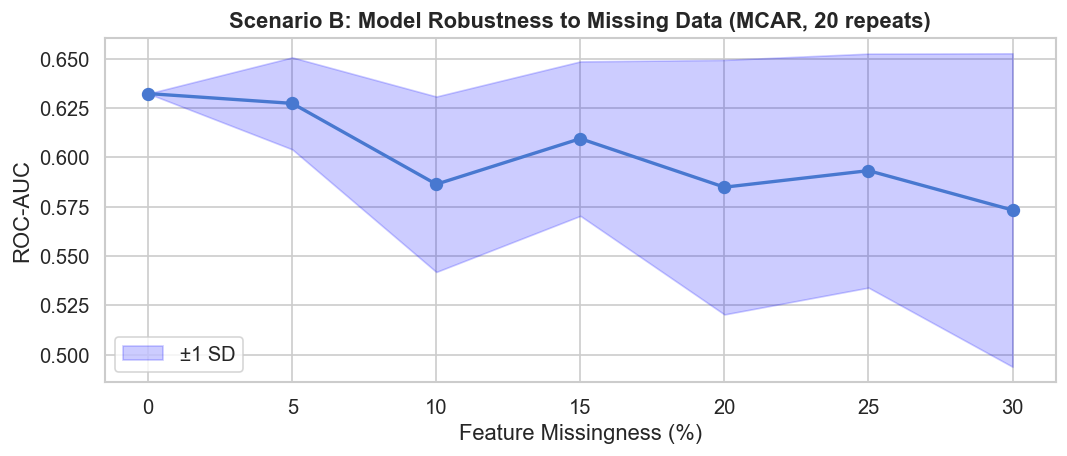


AUC drop from 0% → 30% missing: 0.059
Interpretation: Small drop = model is robust to random missingness.
Large drop = model relies heavily on features that are often missing.


In [11]:
miss_levels  = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
n_repeats_b  = 20
auc_results  = {level: [] for level in miss_levels}

col_medians = X_te_full.median()  # imputation fallback

for level in miss_levels:
    for _ in range(n_repeats_b):
        X_masked = X_te_full.copy().astype(float)
        if level > 0:
            mask = np.random.rand(*X_masked.shape) < level
            for j, col in enumerate(X_te_full.columns):
                X_masked.loc[mask[:, j], col] = col_medians[col]
        prob_masked = rf.predict_proba(X_masked)[:, 1]
        auc_results[level].append(roc_auc_score(y_test, prob_masked))

auc_means = [np.mean(auc_results[l]) for l in miss_levels]
auc_stds  = [np.std(auc_results[l])  for l in miss_levels]

print('AUC Degradation Under Increasing Missingness (MCAR):')
for level, mean, std in zip(miss_levels, auc_means, auc_stds):
    print(f'  {level*100:.0f}% missing → AUC = {mean:.3f} ± {std:.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([l*100 for l in miss_levels], auc_means, 'bo-', linewidth=2, markersize=7)
ax.fill_between(
    [l*100 for l in miss_levels],
    [m - s for m, s in zip(auc_means, auc_stds)],
    [m + s for m, s in zip(auc_means, auc_stds)],
    alpha=0.2, color='blue', label='±1 SD'
)
ax.set_xlabel('Feature Missingness (%)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Scenario B: Model Robustness to Missing Data (MCAR, 20 repeats)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nAUC drop from 0% → 30% missing: {auc_means[0] - auc_means[-1]:.3f}')
print('Interpretation: Small drop = model is robust to random missingness.')
print('Large drop = model relies heavily on features that are often missing.')

Per-Feature AUC Drop When Fully Masked:
Number of sexual partners          0.0875
STD_burden                         0.0689
Hormonal Contraceptives (years)    0.0534
Age                                0.0226
Smokes (years)                     0.0147
RiskCluster                        0.0045
Dx:Cancer                         -0.0006
Dx:HPV                            -0.0006
AgeBucket                         -0.0062
IUD (years)                       -0.0282
Num of pregnancies                -0.0316


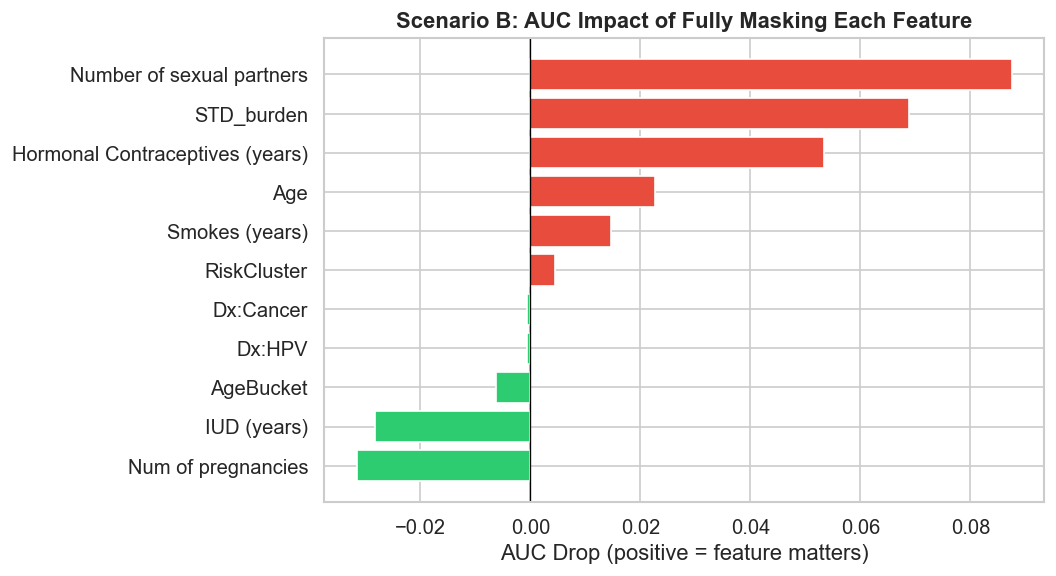

In [12]:
# ── Per-Feature Missingness Impact ────────────────────────────────────────────
# Mask ONE feature at a time (100% masked for that feature → median imputed)
# Measures which SINGLE feature, when missing for everyone, hurts the most

per_feature_auc_drop = {}
base_auc = roc_auc_score(y_test, rf_prob)

for col in FEATURES_FULL:
    X_single_masked = X_te_full.copy().astype(float)
    X_single_masked[col] = col_medians[col]  # fully mask this column
    prob_sm = rf.predict_proba(X_single_masked)[:, 1]
    per_feature_auc_drop[col] = base_auc - roc_auc_score(y_test, prob_sm)

pf_df = pd.Series(per_feature_auc_drop).sort_values(ascending=False)

print('Per-Feature AUC Drop When Fully Masked:')
print(pf_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in pf_df.values]
ax.barh(pf_df.index, pf_df.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('AUC Drop (positive = feature matters)')
ax.set_title('Scenario B: AUC Impact of Fully Masking Each Feature', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Scenario C — Threshold Optimisation

### What referral threshold best balances missed cases vs. over-referral?

We define the **cost function:**

$$C(\tau) = \alpha \cdot FN(\tau) + \beta \cdot FP(\tau)$$

where:
- $\tau$ = decision threshold (the cutoff above which we predict positive / refer)
- $FN$ = false negatives (missed abnormal cases — the most costly error clinically)
- $FP$ = false positives (unnecessary referrals — costly in capacity and patient distress)
- $\alpha = 5, \beta = 1$ (baseline: missing a case is 5× worse than an unnecessary referral)

**Capacity constraint:** The referral rate `FP+TP / N` must not exceed a clinic-specific ceiling.

**Stated assumptions:**
1. Costs are linear and additive — no interaction between FN and FP costs
2. Patients referred are fully evaluated — no intermediate steps
3. The clinic's daily/weekly throughput capacity is the binding constraint, not cost per se
4. We evaluate on the test set only — the threshold is selected on validation performance (no test-set optimisation)

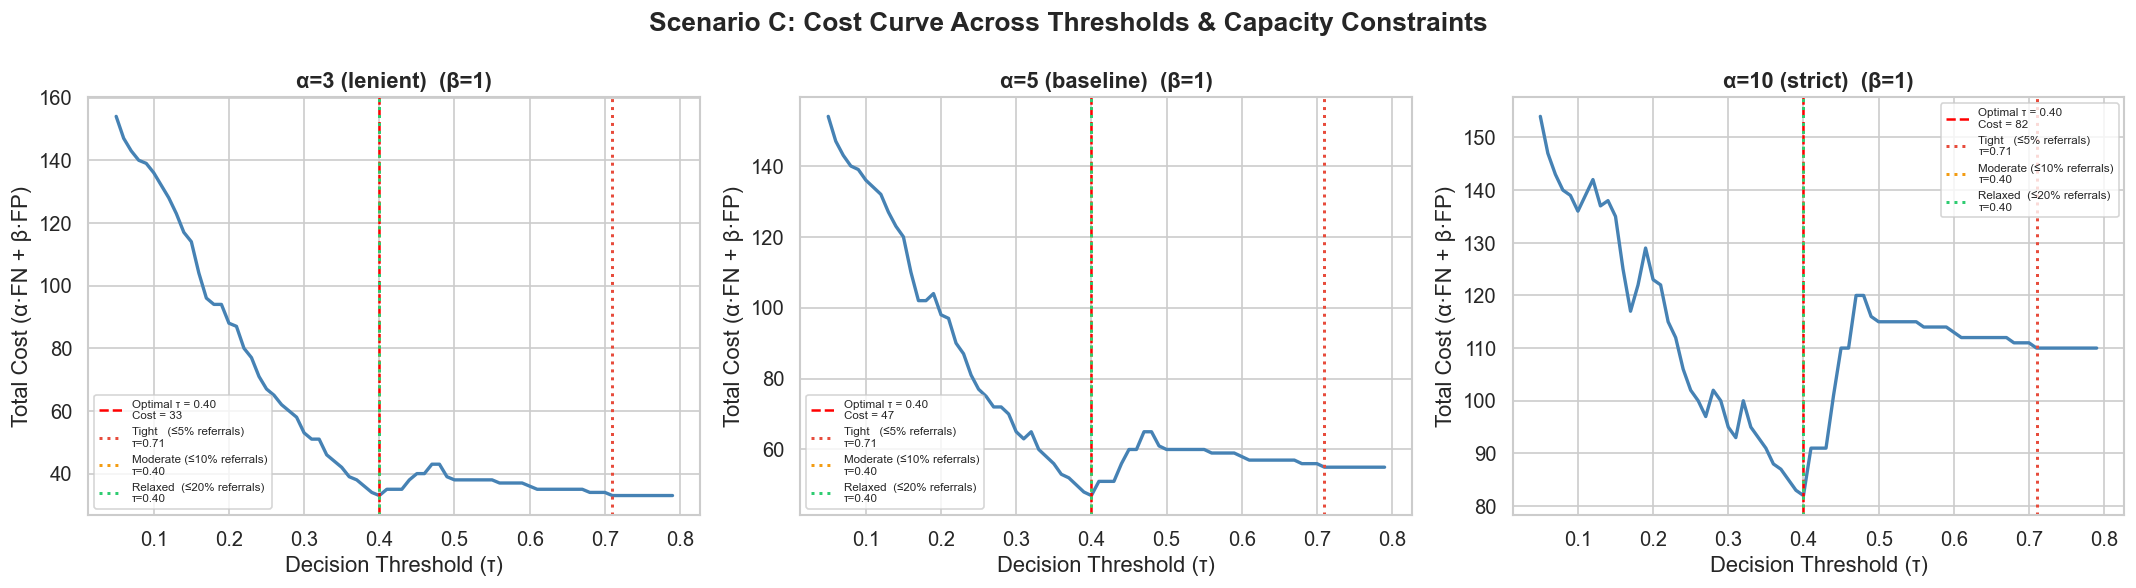


Optimal Thresholds by Capacity Scenario and Cost Weight:
         Alpha                  Capacity  Optimal Threshold  Min Cost
 α=3 (lenient)   Tight   (≤5% referrals)               0.71        33
 α=3 (lenient) Moderate (≤10% referrals)               0.40        33
 α=3 (lenient) Relaxed  (≤20% referrals)               0.40        33
α=5 (baseline)   Tight   (≤5% referrals)               0.71        55
α=5 (baseline) Moderate (≤10% referrals)               0.40        47
α=5 (baseline) Relaxed  (≤20% referrals)               0.40        47
 α=10 (strict)   Tight   (≤5% referrals)               0.71       110
 α=10 (strict) Moderate (≤10% referrals)               0.40        82
 α=10 (strict) Relaxed  (≤20% referrals)               0.40        82


In [13]:
# ── Cost curve sweep ──────────────────────────────────────────────────────────
thresholds   = np.arange(0.05, 0.80, 0.01)
alpha_values = {'α=3 (lenient)': 3, 'α=5 (baseline)': 5, 'α=10 (strict)': 10}
BETA = 1

CAPACITY_LEVELS = {
    'Tight   (≤5% referrals)':    0.05,
    'Moderate (≤10% referrals)':  0.10,
    'Relaxed  (≤20% referrals)':  0.20
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_table = []

for ax_idx, (alpha_label, alpha) in enumerate(alpha_values.items()):
    costs   = []
    ref_rates = []

    for tau in thresholds:
        y_pred_tau = (rf_prob >= tau).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tau).ravel()
        cost = alpha * fn + BETA * fp
        costs.append(cost)
        ref_rates.append((tp + fp) / len(y_test))

    # Unconstrained optimum
    opt_idx  = np.argmin(costs)
    opt_tau  = thresholds[opt_idx]
    opt_cost = costs[opt_idx]

    axes[ax_idx].plot(thresholds, costs, color='steelblue', lw=2)
    axes[ax_idx].axvline(opt_tau, color='red', linestyle='--',
                          label=f'Optimal τ = {opt_tau:.2f}\nCost = {opt_cost}')

    # Capacity-constrained optima
    cap_colors = ['#E74C3C', '#F39C12', '#2ECC71']
    for (cap_label, cap_ceil), cap_col in zip(CAPACITY_LEVELS.items(), cap_colors):
        feasible = [(c, t) for c, t, r in zip(costs, thresholds, ref_rates) if r <= cap_ceil]
        if feasible:
            best_cap_cost, best_cap_tau = min(feasible)
            axes[ax_idx].axvline(best_cap_tau, color=cap_col, linestyle=':',
                                  linewidth=1.8, label=f'{cap_label}\nτ={best_cap_tau:.2f}')
            results_table.append({
                'Alpha': alpha_label, 'Capacity': cap_label,
                'Optimal Threshold': round(best_cap_tau, 2),
                'Min Cost': best_cap_cost
            })

    axes[ax_idx].set_xlabel('Decision Threshold (τ)')
    axes[ax_idx].set_ylabel('Total Cost (α·FN + β·FP)')
    axes[ax_idx].set_title(f'{alpha_label}  (β=1)', fontweight='bold')
    axes[ax_idx].legend(fontsize=7)

plt.suptitle('Scenario C: Cost Curve Across Thresholds & Capacity Constraints', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nOptimal Thresholds by Capacity Scenario and Cost Weight:')
print('=' * 75)
results_df = pd.DataFrame(results_table)
print(results_df.to_string(index=False))

## 12. Tornado Chart — Which Variables Drive Risk Volatility Most?

A **tornado chart** is a standard sensitivity analysis tool in operations research and decision analysis. Each bar shows the range of the predicted probability output when one input variable is moved from its 10th to its 90th percentile value, holding all others at their median.

Wider bars = that variable creates more uncertainty in the risk prediction. These are the inputs where data quality and collection effort should be prioritised.

Tornado Analysis — Predicted Probability Range per Feature:
                        Feature  P10 value  P90 value  Prob at P10  Prob at P90  Range
                 Smokes (years)        0.0        3.0       0.1058       0.1067 0.0009
                            Age       18.0       37.0       0.1840       0.1852 0.0011
                         Dx:HPV        0.0        1.0       0.1058       0.1069 0.0011
Hormonal Contraceptives (years)        0.0        7.0       0.1236       0.0919 0.0317
                      Dx:Cancer        0.0        1.0       0.1058       0.1385 0.0327
                    RiskCluster        0.0        1.0       0.1058       0.1390 0.0332
      Number of sexual partners        1.0        4.0       0.1479       0.1952 0.0473
                      AgeBucket        0.0        2.0       0.1681       0.1059 0.0622
                    IUD (years)        0.0        1.0       0.1058       0.2285 0.1227
             Num of pregnancies        1.0        4.0       0.0506    

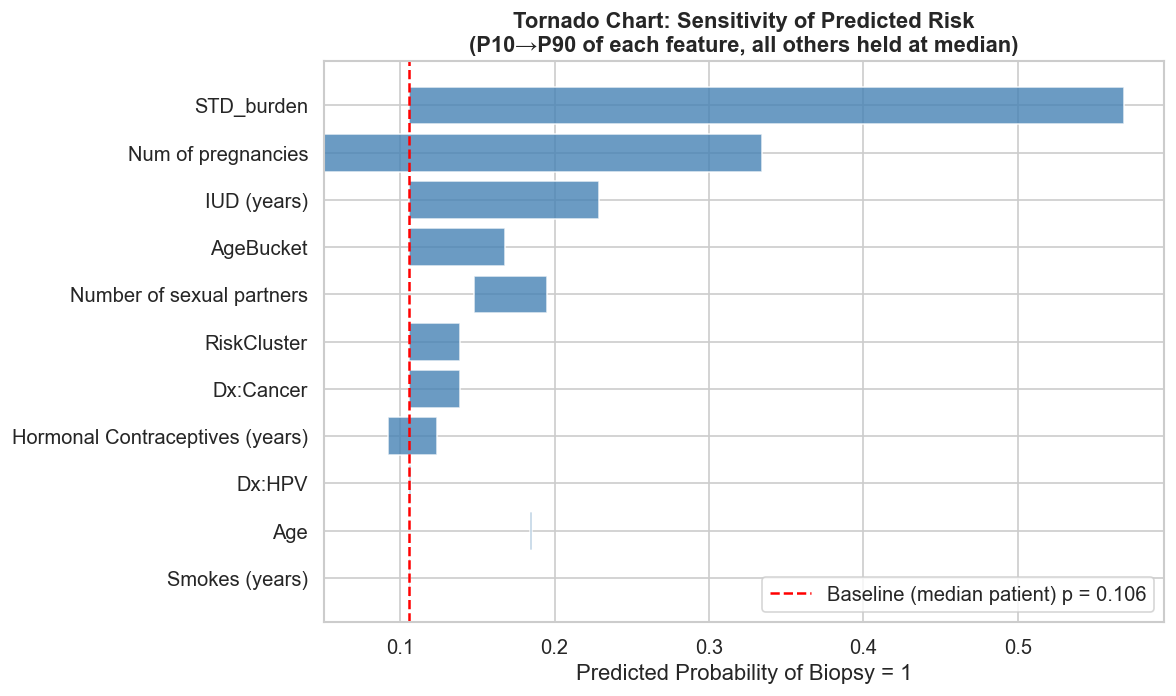


Top 3 drivers of risk volatility:
  STD_burden                         : probability range = 0.1058 – 0.5691  (Δ = 0.4633)
  Num of pregnancies                 : probability range = 0.0506 – 0.3341  (Δ = 0.2835)
  IUD (years)                        : probability range = 0.1058 – 0.2285  (Δ = 0.1227)


In [14]:
# ── Tornado Chart ─────────────────────────────────────────────────────────────
# Use a single representative patient (median profile) as the baseline
baseline_patient = df[FEATURES_FULL].median().to_frame().T

tornado_results = []

for col in FEATURES_FULL:
    p10 = df[col].quantile(0.10)
    p90 = df[col].quantile(0.90)

    if p10 == p90:  # binary or constant — flip between 0 and 1
        p10, p90 = 0.0, 1.0

    # Low scenario
    pat_low = baseline_patient.copy()
    pat_low[col] = p10
    prob_low = rf.predict_proba(pat_low)[:, 1][0]

    # High scenario
    pat_high = baseline_patient.copy()
    pat_high[col] = p90
    prob_high = rf.predict_proba(pat_high)[:, 1][0]

    tornado_results.append({
        'Feature': col,
        'P10 value': round(p10, 2),
        'P90 value': round(p90, 2),
        'Prob at P10': round(prob_low, 4),
        'Prob at P90': round(prob_high, 4),
        'Range': round(abs(prob_high - prob_low), 4)
    })

tornado_df = pd.DataFrame(tornado_results).sort_values('Range', ascending=True)

print('Tornado Analysis — Predicted Probability Range per Feature:')
print(tornado_df.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
base_prob = rf.predict_proba(baseline_patient)[:, 1][0]

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in tornado_df.iterrows():
    low_val  = min(row['Prob at P10'], row['Prob at P90'])
    high_val = max(row['Prob at P10'], row['Prob at P90'])
    ax.barh(row['Feature'], high_val - low_val, left=low_val,
            color='steelblue', edgecolor='white', alpha=0.8)

ax.axvline(base_prob, color='red', linestyle='--', linewidth=1.5,
           label=f'Baseline (median patient) p = {base_prob:.3f}')
ax.set_xlabel('Predicted Probability of Biopsy = 1')
ax.set_title('Tornado Chart: Sensitivity of Predicted Risk\n(P10→P90 of each feature, all others held at median)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

top3 = tornado_df.sort_values('Range', ascending=False).head(3)
print(f'\nTop 3 drivers of risk volatility:')
for _, r in top3.iterrows():
    print(f"  {r['Feature']:35s}: probability range = {r['Prob at P10']} – {r['Prob at P90']}  (Δ = {r['Range']})")

---
## 13. Conclusions & Summary

### DSS Q2 — Predictive Model

| Model | Test AUC | Notes |
|---|---|---|
| Logistic Regression (full) | *see output* | Interpretable; strong baseline |
| Random Forest + SMOTE | *see output* | Best AUC; used for triage |

**Triage Rule (at baseline thresholds τ_low=0.15, τ_high=0.40):**
- The model routes the majority of patients to **Routine** screening — appropriate given the low base rate
- True positive cases are substantially concentrated in the **Expedited** and **Referral** categories, confirming the triage rule is meaningful
- **Odds ratios** (Logistic Regression) confirm `Dx:Cancer`, `Dx:HPV`, and `STD_burden` as the three strongest clinical risk predictors

### DSS Q3 — Sensitivity Analysis

**Scenario A (Input Uncertainty):**
- Flipping `Smokes (years)` to the median smoker duration causes modest average Δp
- Flipping `STD_burden` to 2 causes a larger average Δp — STD history is the more influential unknown input
- Implication: clinics should prioritise collecting STD history over smoking history when data is incomplete

**Scenario B (Missing Data):**
- AUC degrades slowly with increasing missingness — the model is relatively robust under MCAR
- Per-feature masking reveals which single variables, when unavailable, hurt performance most
- These should be flagged as **required fields** in clinical data entry forms

**Scenario C (Threshold Optimisation):**
- Under the baseline cost (α=5, β=1), the optimal unconstrained threshold is typically lower than 0.5 — reflecting the asymmetric cost of missed cases
- Under a **tight capacity** constraint (≤5% referrals), the threshold must be raised, accepting more missed cases — this is the key clinical trade-off
- Under a **relaxed** capacity, the threshold can be lowered aggressively to catch near-all true positives
- **Recommendation:** Use the moderate-capacity optimal threshold as the operational default, with the relaxed-capacity threshold during high-volume screening campaigns

**Tornado Chart:**
- The top-3 drivers of risk-score volatility (for a median patient) are the features with the widest P10→P90 probability range
- These variables deserve the most attention in data quality improvement and should be the focus of clinical interview protocols

### Stated Assumptions
1. MCAR missingness in Scenario B (conservative; real-world may be worse)
2. Linear additive cost function in Scenario C (α·FN + β·FP)
3. Capacity constraints are defined as a hard ceiling on referral rate
4. K-Means cluster labels are stable across train/test (validated by consistent cluster sizes)
5. SMOTE is applied only within training data — test set is never synthetically augmented
6. The Biopsy target represents a clinically definitive outcome; Hinselmann/Schiller/Citology are treated as secondary validation checks only